# hatchsvg — Explore

**Goal:** understand what each step of the pipeline does, and how the parameters interact.

Read the markdown cells — they explain *why*, not just *what*.

When you see a `2a` / `2b` / `2c` heading, those are alternative paths; pick the one that matches your use case.

## The 4 stages

1. **Load** — read the image, convert to RGBA

2. **Quantize** — find the dominant colors. **Three alternative paths (2a/2b/2c) depending on what kind of input you have.**

3. **Render** — generate the hatch paths (the slow step, 30-60s)

4. **Save & reproduce** — write the SVG and a session file so you can come back to this exact render later

## Stage 1 — Load

The image loader is dumb on purpose: it opens whatever Pillow can decode and converts to RGBA.

The algorithm doesn't care about the original mode; it only cares about pixel values + alpha.

If your image has a soft alpha channel (e.g. a PNG with feathered edges),

the `alpha_threshold` parameter (in Stage 2) controls which pixels get rendered.

Loaded: 1402x1903 RGBA


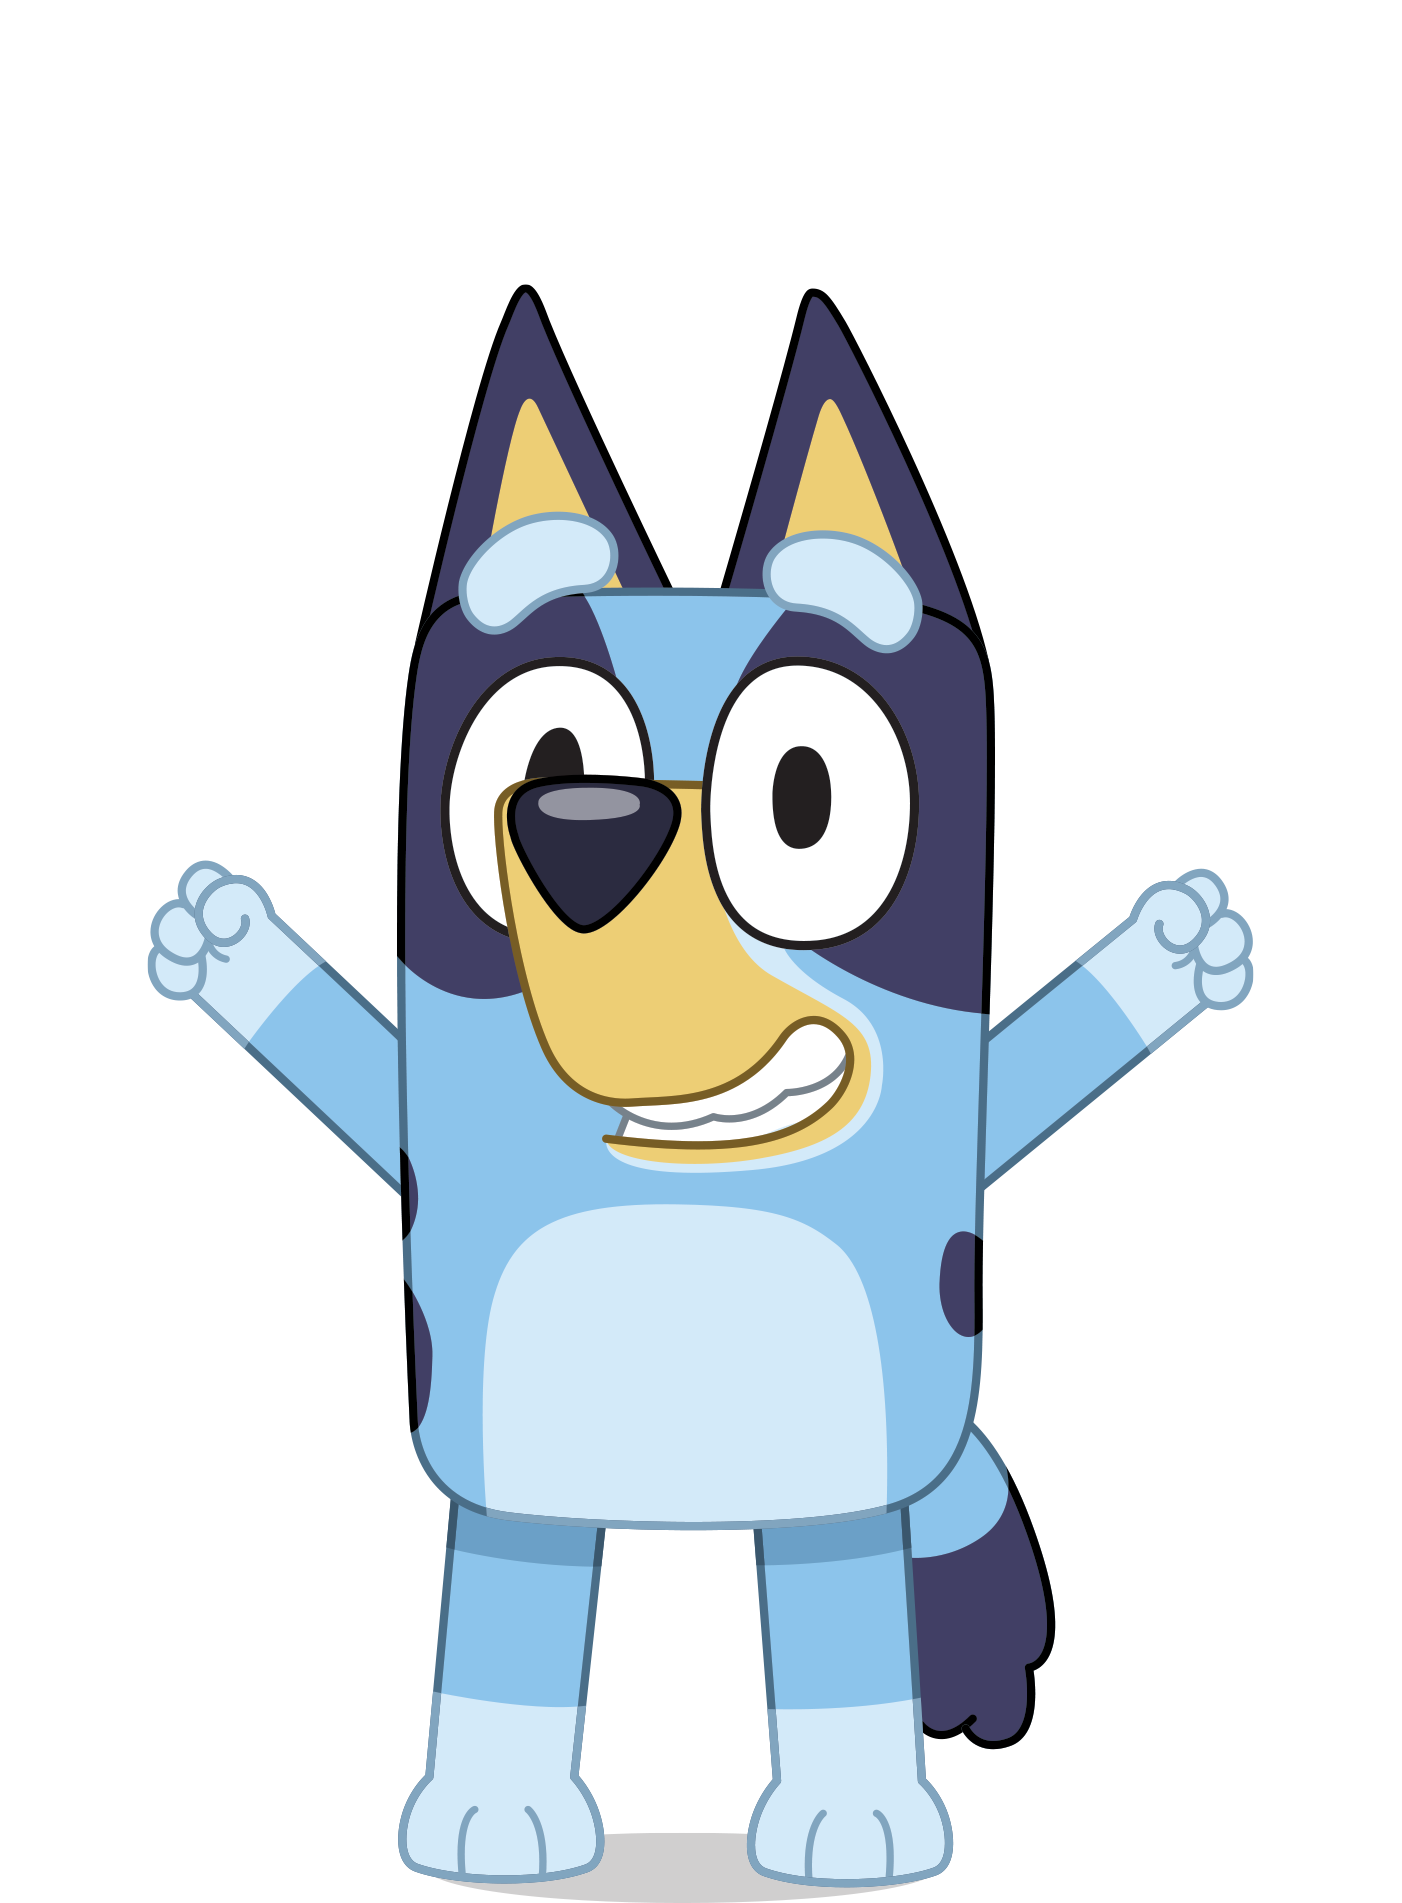

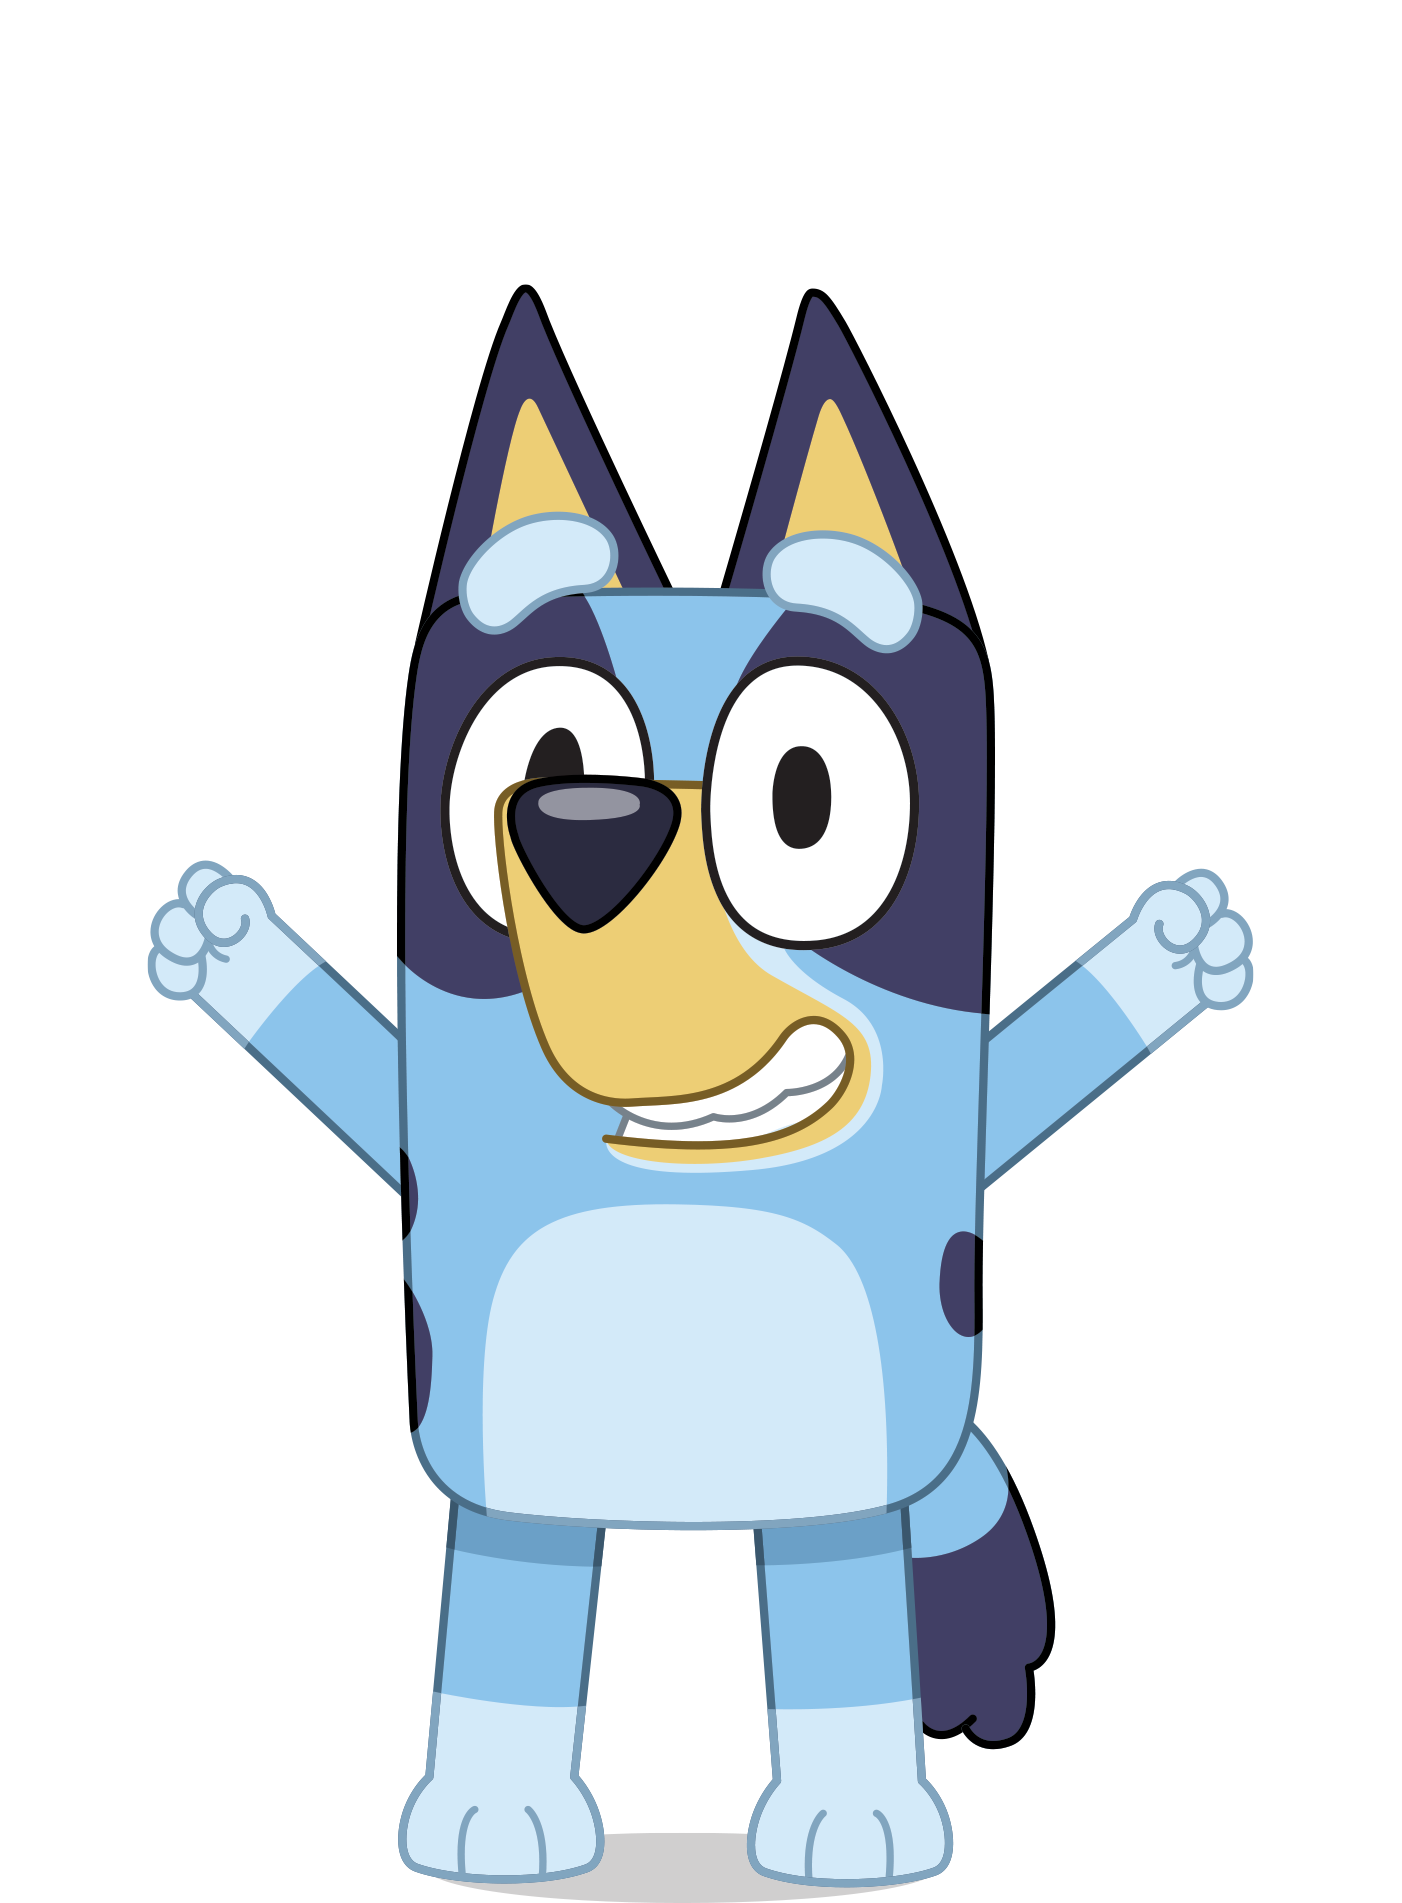

In [1]:
from pathlib import Path
import notebook_helpers as nh
from IPython.display import display, Markdown

img = nh.load_image("../Bluey.png")
print(f"Loaded: {img.size[0]}x{img.size[1]} {img.mode}")
nh.display_image(img)

## Stage 2 — Quantize

Quantization is the **fast** part of the pipeline (~200-300ms on a 1500x2000 image).

It collapses thousands of unique colors into a small palette. The actual SVG hatching is much

more expensive; doing quantization first lets you iterate on color choices quickly.



There are three sub-paths depending on what you have:



- **2a.** You have a physical marker set (Crayola, Jot, Copic, your own) — use palette matching

- **2b.** You have a photo or complex image with no fixed pen set — use plain k-means quantize

- **2c.** You have a logo or line art with very few colors — use aggressive quantize

### Stage 2a — Quantize with a physical marker palette

This is the path that makes hatchsvg a *physical-pen* tool, not a generic tracer.

We map each detected color to the **closest marker you actually own**.



Bundled palettes: `crayola_10ct_fine_line_classic`, `jot_20ct_washable_fineline`.

You can also pass a path to a custom JSON palette (see `craft.ipynb`).

Palette: Crayola 10ct Fine Line Classic, 10 colors, tip 0.8mm
Quantizing: Found 4548 unique colors > max_palette=6.


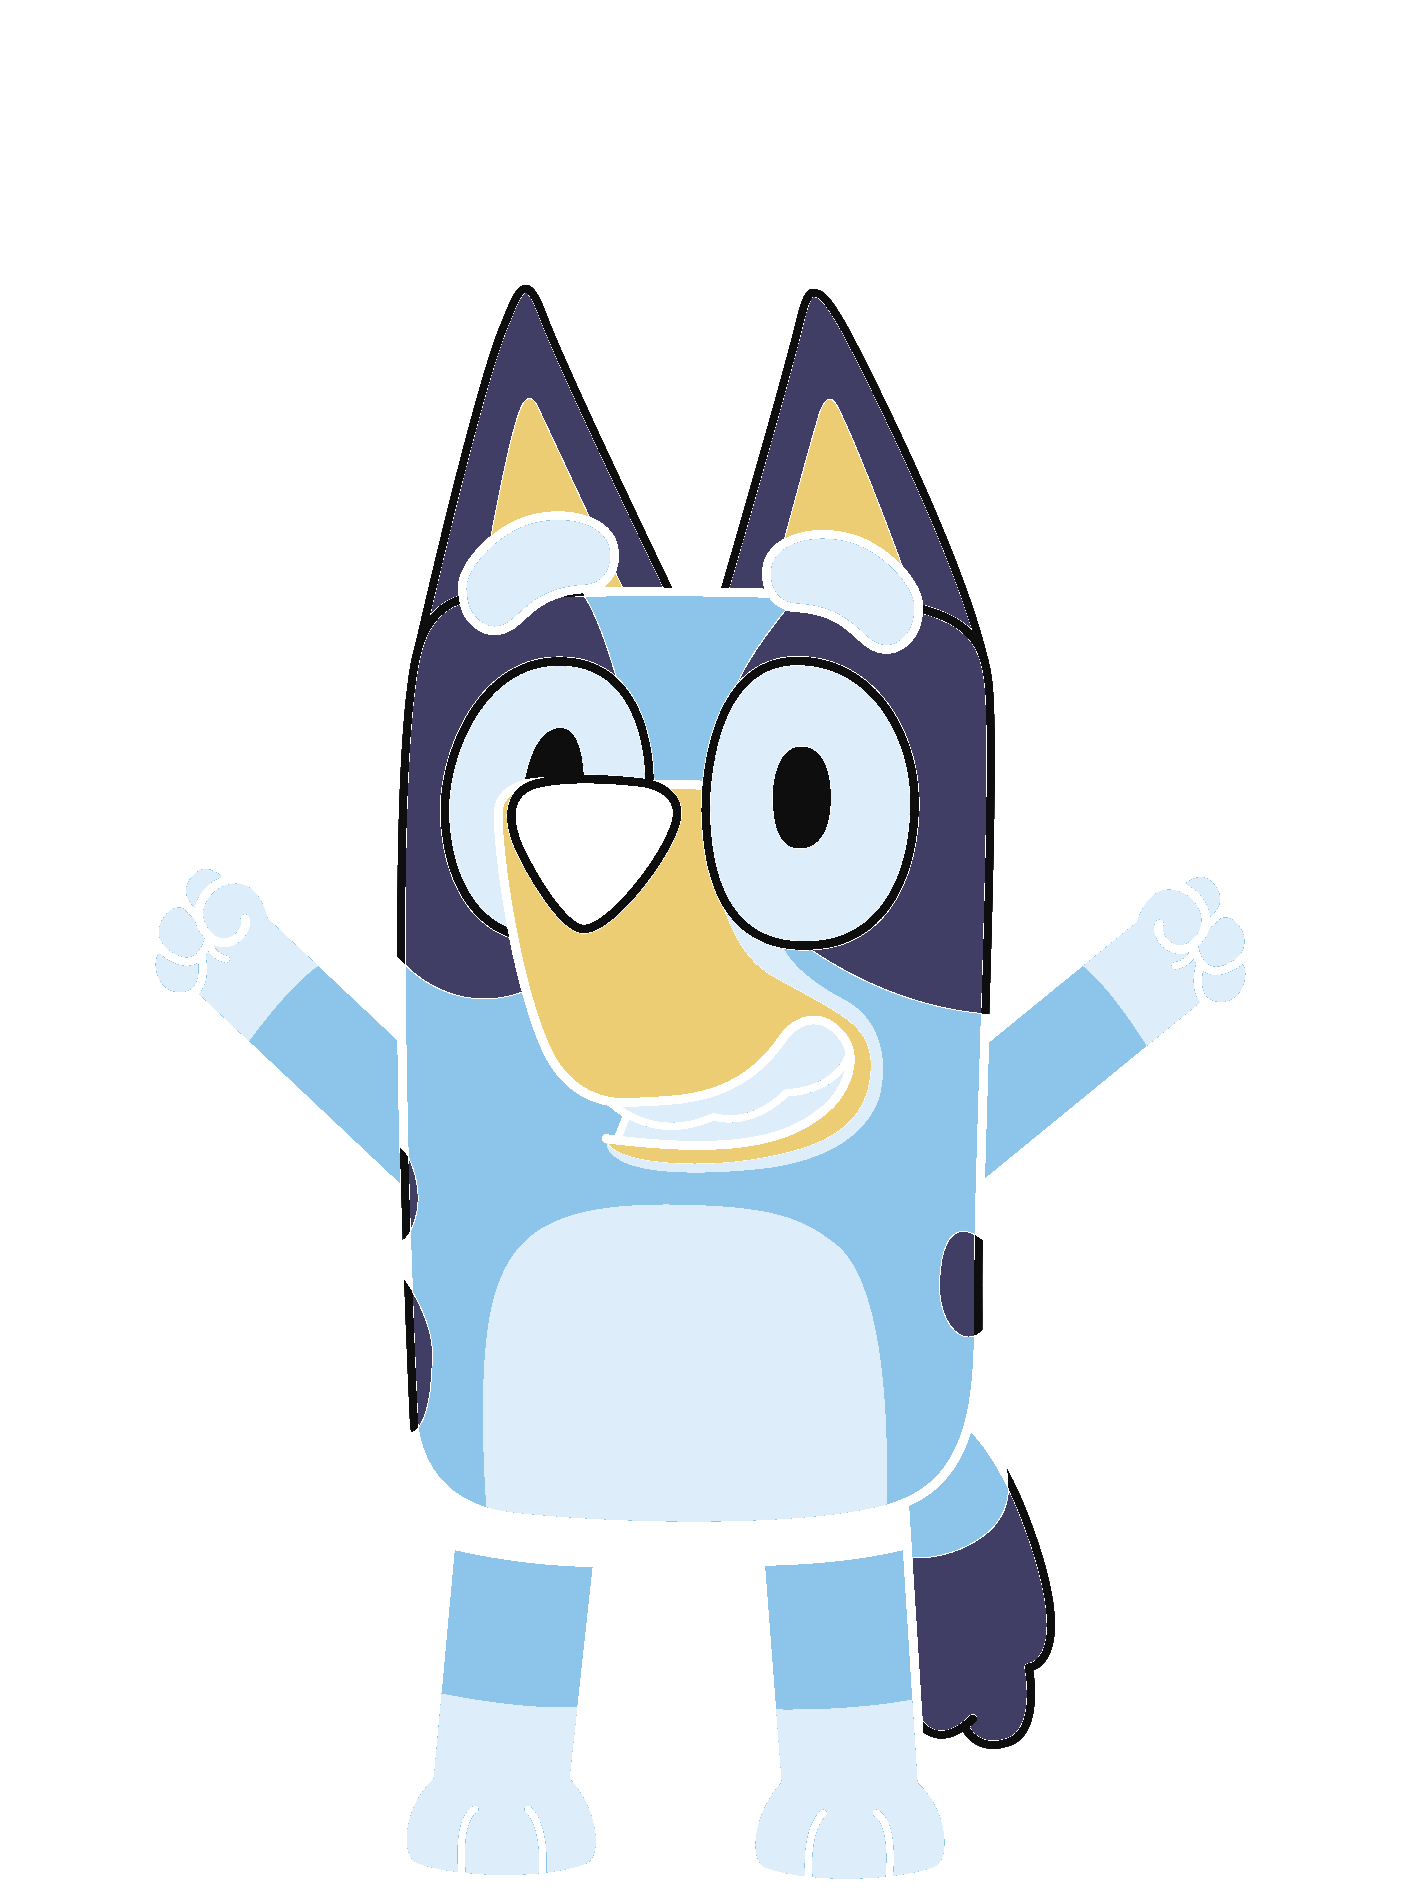

**Quantized** — 6 colors:

| # | Color | Hex | Pixels | % of visible |
|---|-------|-----|--------|--------------|
| 0 | white | `#FFFFFF` | 115,428 | 13.3% |
| 1 | cyan | `#DDEEFA` | 287,850 | 33.1% |
| 2 | cyan | `#8CC4EA` | 219,615 | 25.2% |
| 3 | blue | `#403E64` | 134,086 | 15.4% |
| 4 | orange | `#ECCD74` | 66,872 | 7.7% |
| 5 | black | `#0F0E0F` | 46,293 | 5.3% |

In [2]:
palette = nh.load_palette("crayola_10ct_fine_line_classic")
print(
    f"Palette: {palette['brand']} {palette['set_name']}, {len(palette['colors'])} colors, tip {palette['tip_width_mm']}mm"
)

quant = nh.quantize_image(img, max_palette=6)
matched = nh.match_to_palette(quant, palette)

preview = nh.render_quantized_preview(img, matched)
nh.display_image(preview)
display(Markdown(nh.format_quantize_report(matched)))

**Reading the report:**

- The `Hex` column is the color detected in your image

- The marker mapping is `closest_marker()` — by default, HSV Euclidean distance

- If the marker mapping is wrong, you'll see e.g. `#FFFFFF` mapped to `Gray` — that means your

  lightest color is closer to gray than to any white-ish marker in the palette. Solutions:

  - Increase `max_palette` so a true white is detected separately

  - Use a palette that has a true white marker

  - Skip palette matching (use Stage 2b) and accept the raw quantized colors

### Stage 2b — Quantize without a marker palette (photos, complex images)

If you don't have a fixed pen set, you can quantize to a generic palette and let the SVG

use the raw colors. The pen plotter will still draw it, but you're not constrained to

markers you actually own.



This is the same as Stage 2a minus the `match_to_palette` call — simpler, but less 'real'.

Quantizing: Found 4548 unique colors > max_palette=8.


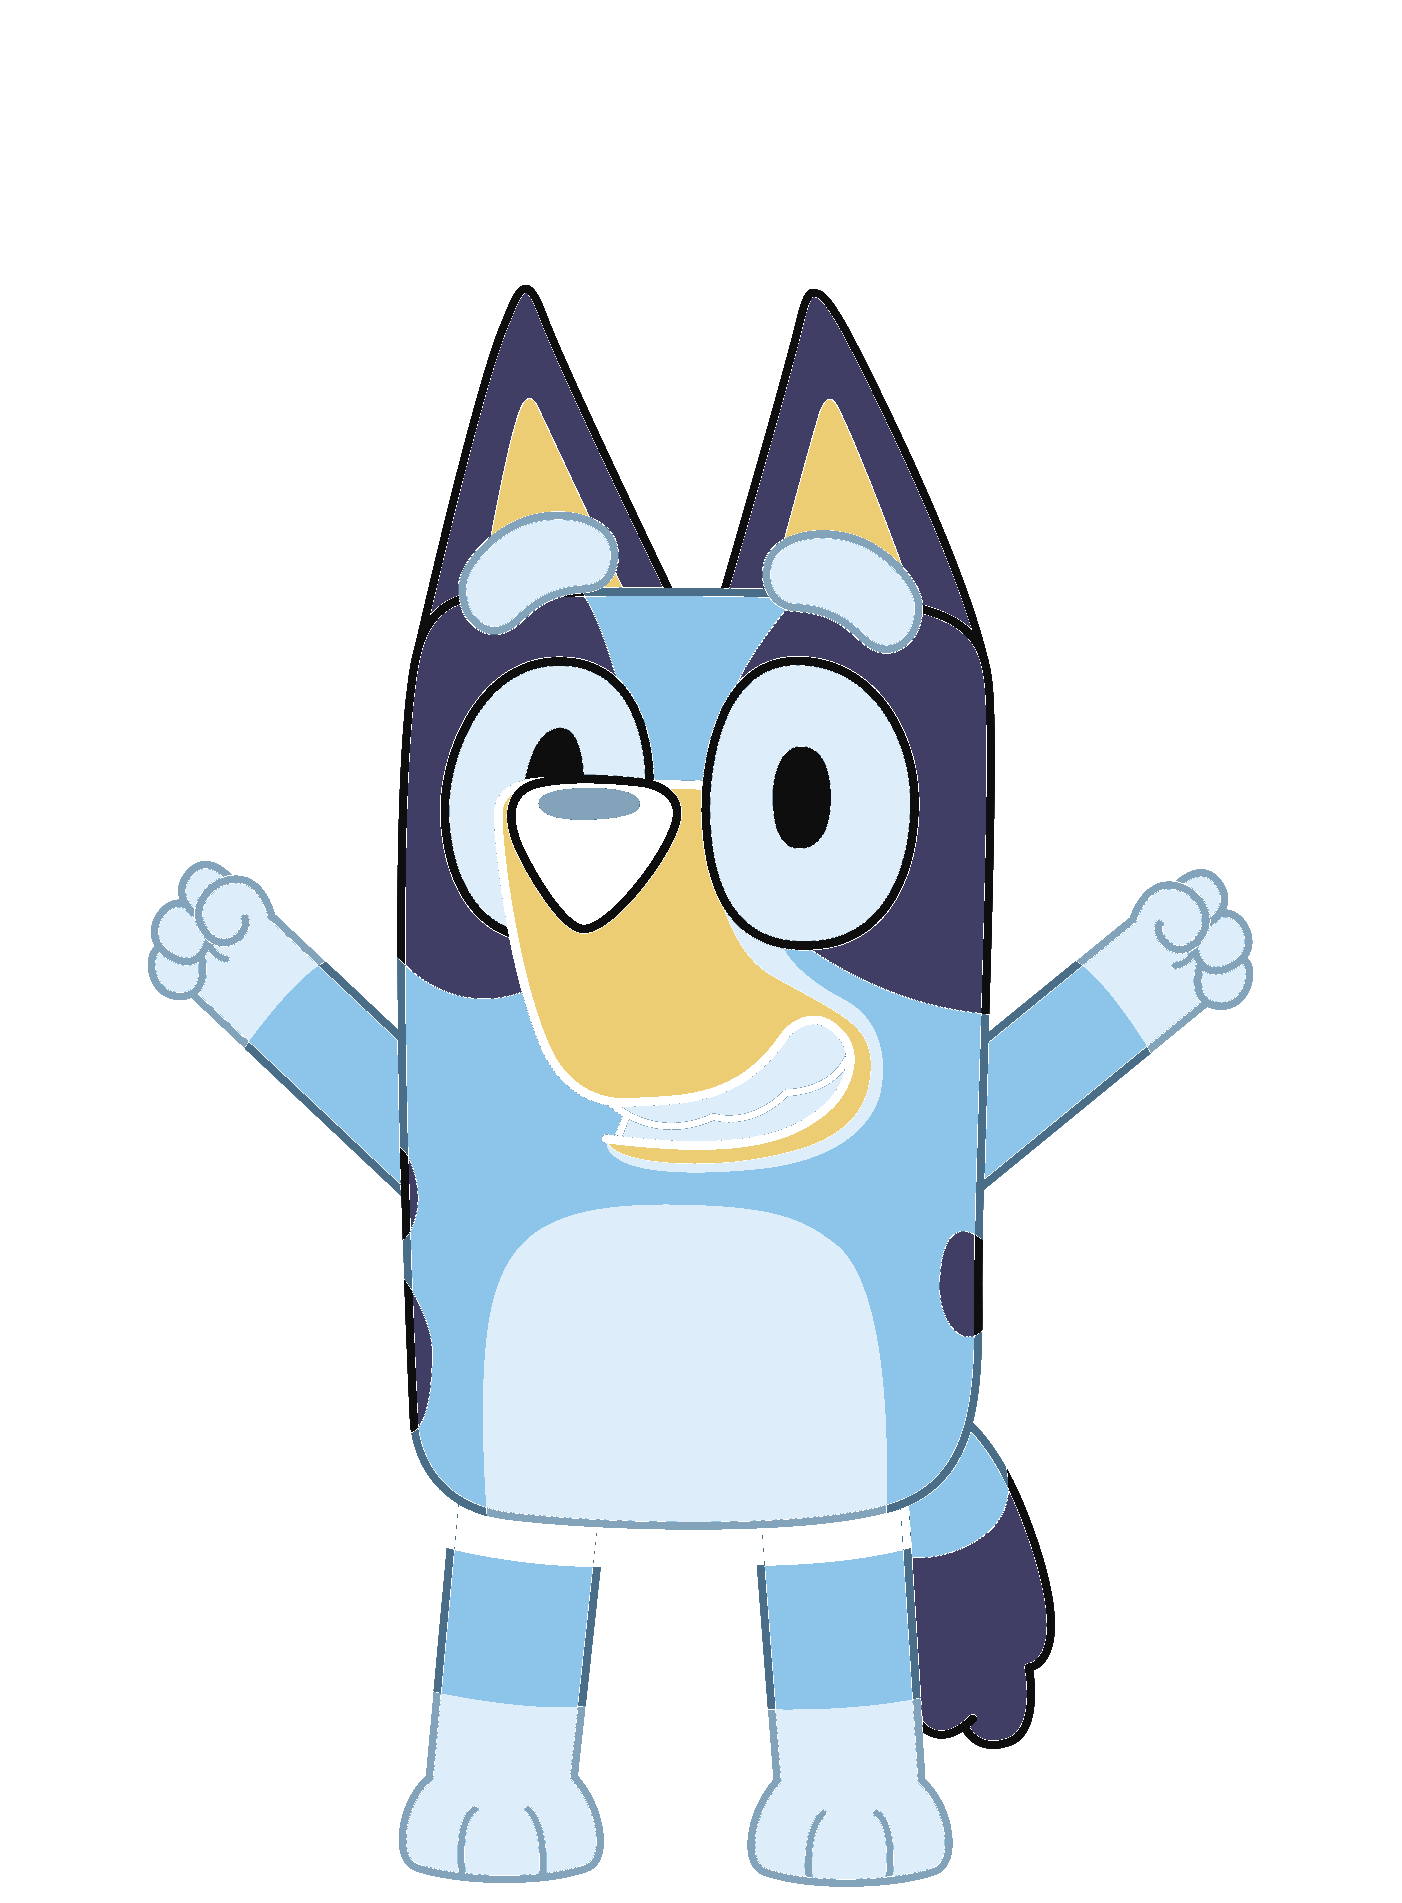

**Quantized** — 8 colors:

| # | Color | Hex | Pixels | % of visible |
|---|-------|-----|--------|--------------|
| 0 | white | `#FFFFFF` | 64,945 | 7.5% |
| 1 | cyan | `#DDEEFA` | 287,850 | 33.1% |
| 2 | cyan | `#8CC4EA` | 219,615 | 25.2% |
| 3 | blue | `#403E64` | 134,086 | 15.4% |
| 4 | orange | `#ECCD74` | 66,872 | 7.7% |
| 5 | black | `#0F0E0F` | 46,293 | 5.3% |
| 6 | cyan | `#83A3BB` | 32,418 | 3.7% |
| 7 | cyan | `#4B6E88` | 18,065 | 2.1% |

In [3]:
quant = nh.quantize_image(img, max_palette=8)
preview = nh.render_quantized_preview(img, quant)
nh.display_image(preview)
display(Markdown(nh.format_quantize_report(quant)))

### Stage 2c — Aggressive quantize for logos and line art

For graphics with 2-4 distinct colors, force `max_palette=4` (or even less).

This gives you the cleanest banded look. Pair with `--no-skip-background` if you want

the background to be a layer (we set `skip_bg=False` here).

Quantizing: Found 4548 unique colors > max_palette=4.


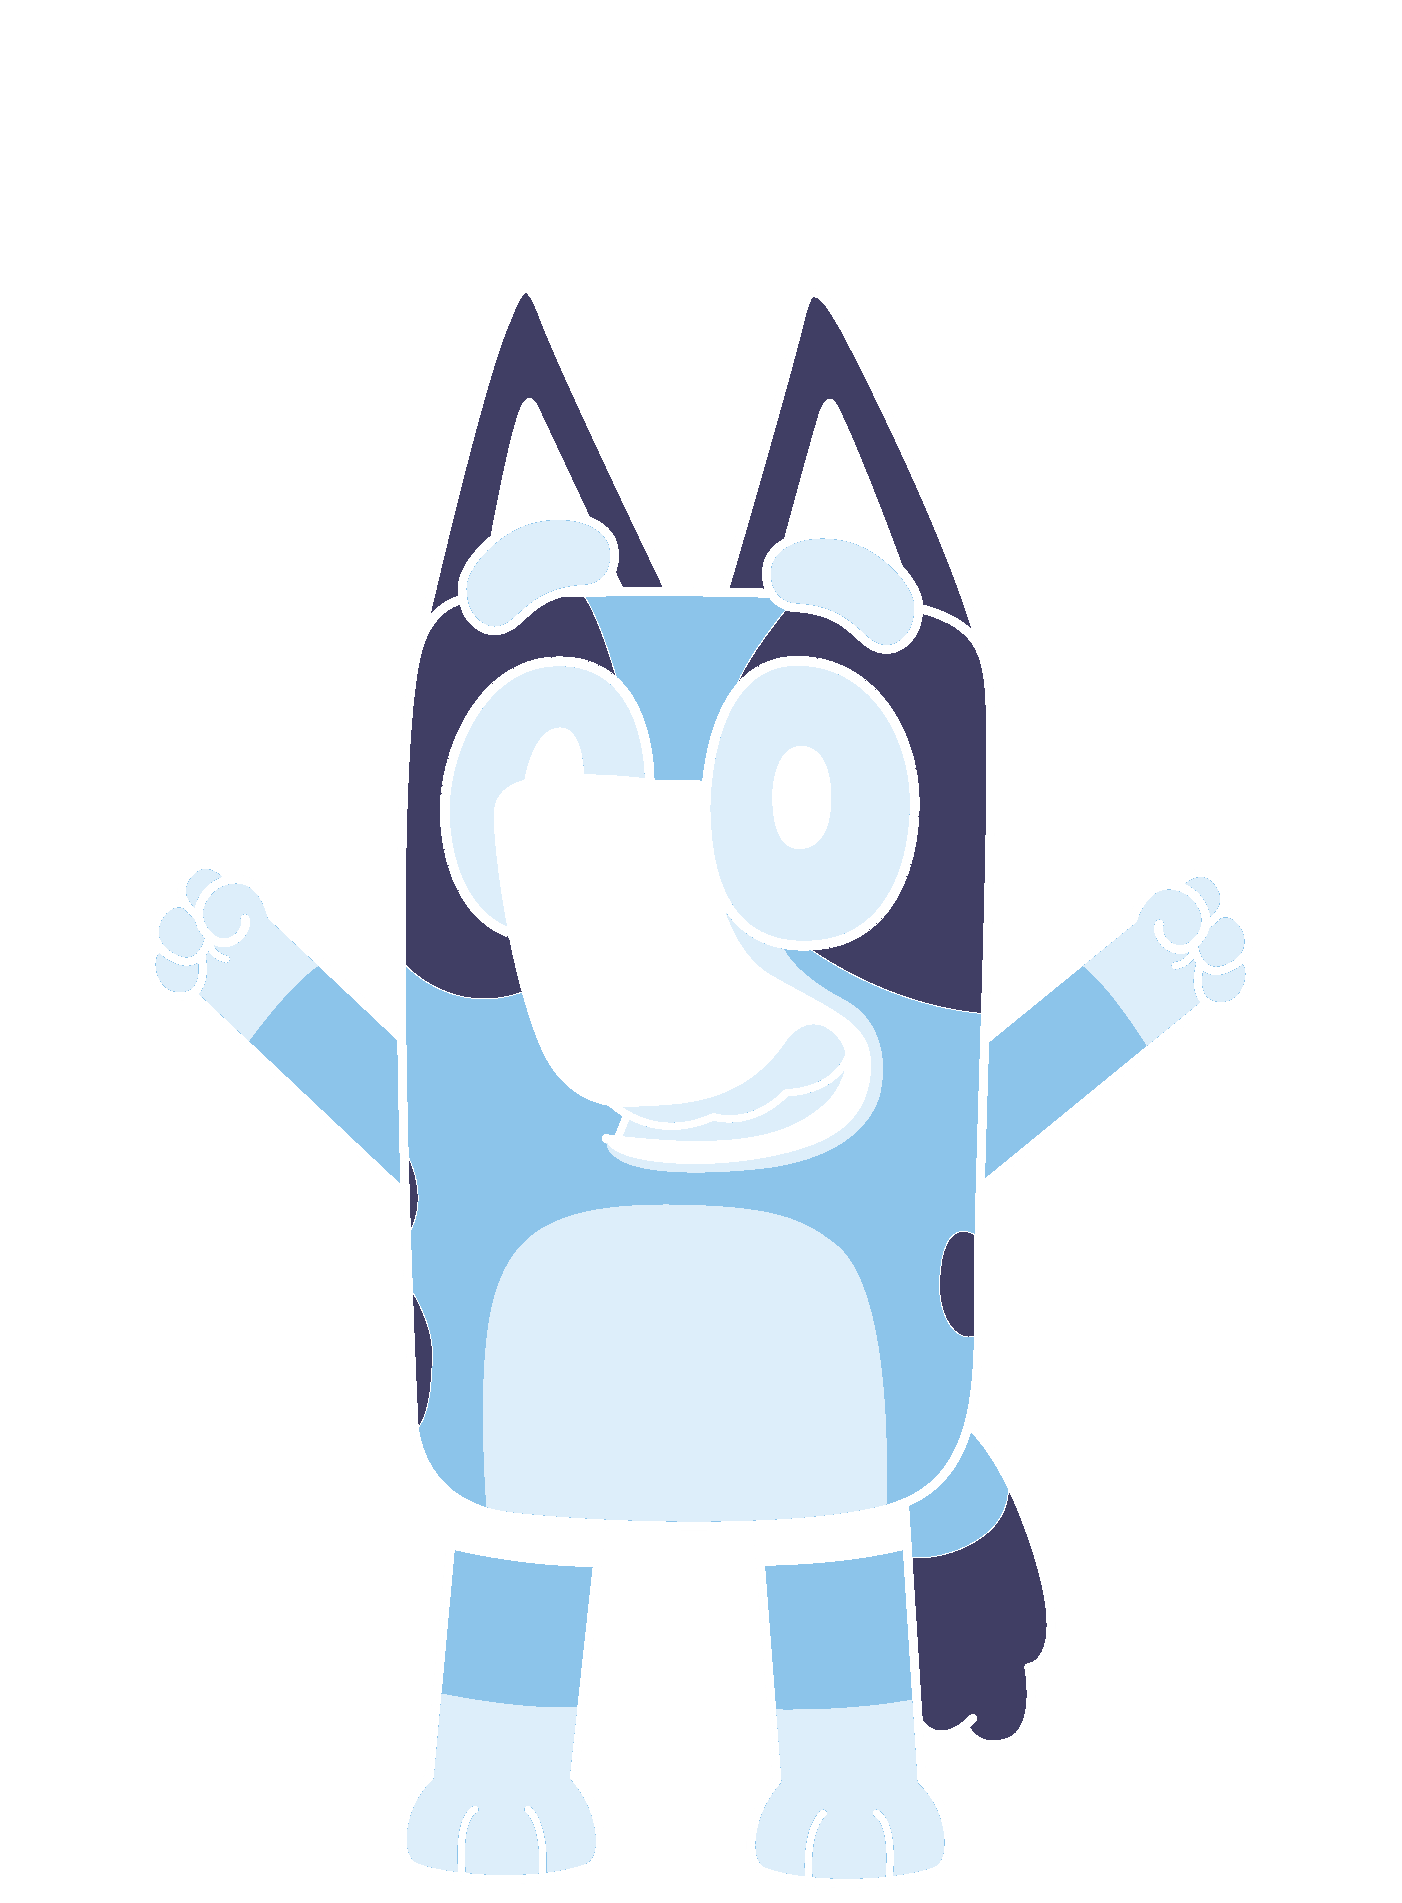

**Quantized** — 4 colors:

| # | Color | Hex | Pixels | % of visible |
|---|-------|-----|--------|--------------|
| 0 | white | `#FFFFFF` | 228,593 | 26.3% |
| 1 | cyan | `#DDEEFA` | 287,850 | 33.1% |
| 2 | cyan | `#8CC4EA` | 219,615 | 25.2% |
| 3 | blue | `#403E64` | 134,086 | 15.4% |

In [4]:
quant = nh.quantize_image(img, max_palette=4, skip_bg=False)
preview = nh.render_quantized_preview(img, quant)
nh.display_image(preview)
display(Markdown(nh.format_quantize_report(quant)))

## Stage 3 — Render the hatch paths

**This is the slow step.** It iterates pixel-by-pixel to generate the hatch lines.

On a 1500x2000 image, expect 30-60 seconds.



**Always validate your color choices in Stage 2 first.** Re-running Stage 3 with bad

parameters wastes time. Use Stage 2's preview to confirm:

1. The number of colors is right

2. The marker mapping is right (if using a palette)

3. The background is handled correctly (skipped or not, per your preference)

Quantizing: Found 4548 unique colors > max_palette=6.


Loading image: /tmp/hatchsvg_notebook_input.png

Quantizing: Found 4548 unique colors > max_palette=8.


Colors used: 8

Background detected as index 0, RGB=(255, 255, 255)


...

idx 5: Black (#000000) RGB=(15, 14, 15), L=14.3, white=False, pixels=46293, ls=5


idx 6: Blue (#1E4DB7) RGB=(131, 163, 187), L=157.9, white=False, pixels=32418, ls=3


idx 7: Blue (#1E4DB7) RGB=(75, 110, 136), L=104.4, white=False, pixels=18065, ls=3


Saved 7 color layers to /tmp/hatchsvg_notebook_output.svg (separate_outline=False, naming_mode=inkscape)

**Rendered**

- Layers: 7
- Total segments: 6,394
- Pen lifts (optimized): 4,785
- Pen lifts (legacy): 6,394
- Pen-lift reduction: 25.2%
- Output: `/tmp/hatchsvg_notebook_output.svg`

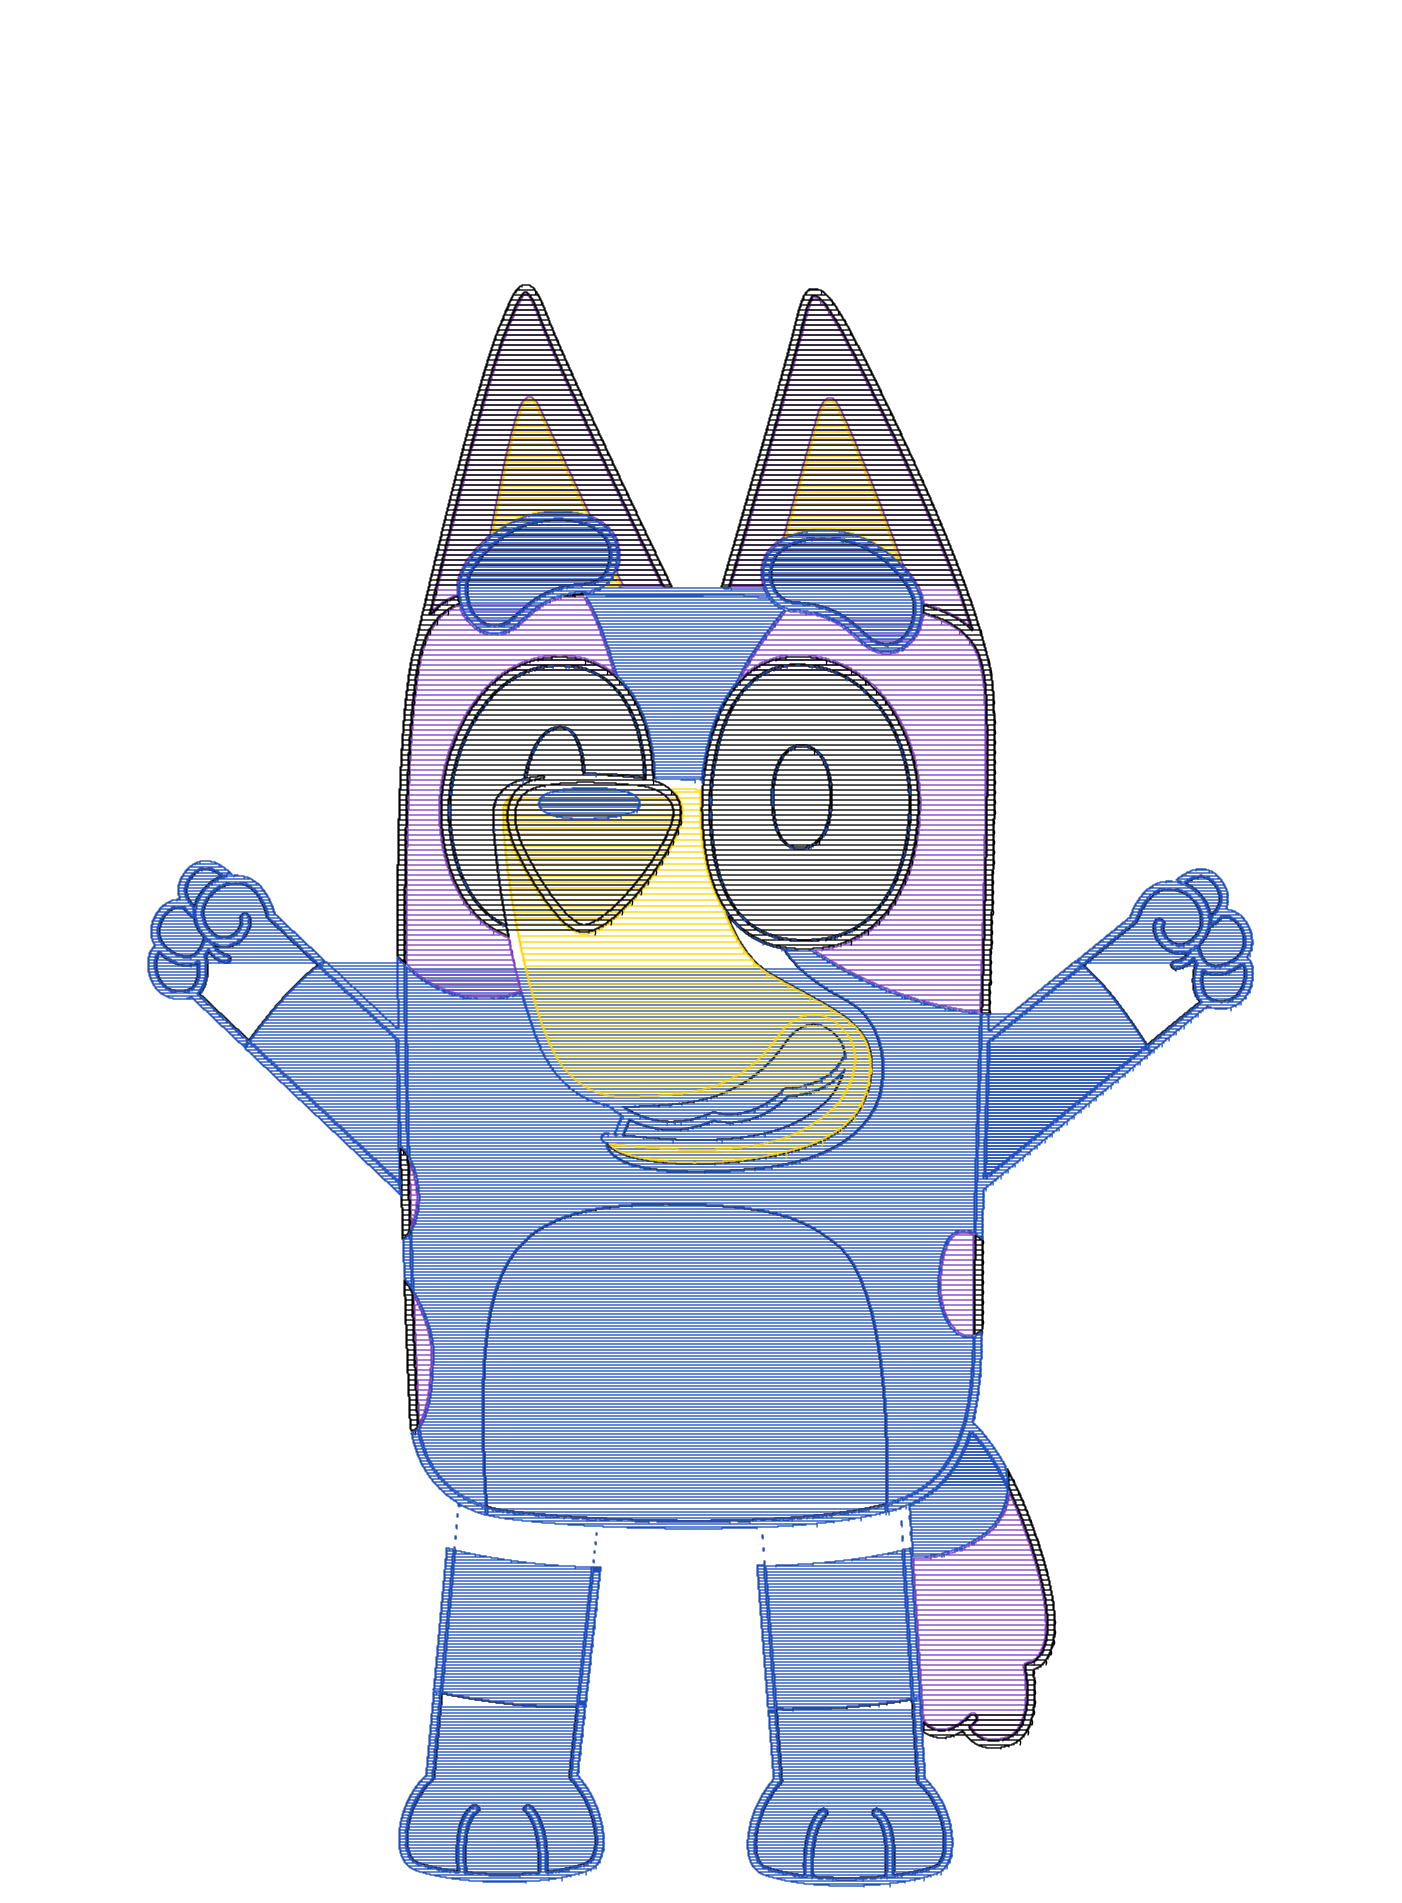

In [5]:
# Use the matched quant from Stage 2a (palette-aware)
quant = nh.quantize_image(img, max_palette=6)
matched = nh.match_to_palette(quant, palette)

result = nh.render_svg(
    img,
    preset="portrait",
    palette=palette,
    max_palette=6,
    line_step=4,
    continuous_paths=True,
    arc_radius=5.0,
)
display(Markdown(nh.format_render_report(result)))
nh.display_svg(result["svg_path"])

## Stage 4 — Save & reproduce

Save the SVG to a friendly name AND a session JSON. The session JSON captures every

input — image path, params, palette, color mapping — so you can come back to this exact

render months later by loading the session and re-running.



Why bother? Because you'll iterate: 'this is close, but with a 6-color palette and arc_radius 3

it's better' — and then lose the settings. The session file is the recipe.

In [6]:
import shutil
from pathlib import Path

# Save the SVG with a friendlier name
svg_out = Path("explore_output.svg")
shutil.copy(result["svg_path"], svg_out)
print(f"SVG: {svg_out.absolute()} ({svg_out.stat().st_size:,} bytes)")

# Save the session (params + palette + color map) for reproducibility
from hatchsvg.core import RenderParams

session = nh.snapshot_session(
    params=RenderParams(**result["params"]),
    palette=palette,
    color_map=result["color_map_used"],
    image_path="../Bluey.png",
)
session_path = Path("explore_session.json")
nh.save_session_file(session, session_path)
print(f"Session: {session_path.absolute()} ({session_path.stat().st_size:,} bytes)")

SVG: /home/jcharles/Projects/python/png2svg/notebooks/explore_output.svg (1,061,484 bytes)
Session: /home/jcharles/Projects/python/png2svg/notebooks/explore_session.json (3,990 bytes)


## What now?

You should now have an intuition for what each stage does. Open `craft.ipynb` for:

- Custom marker palettes (your own pen set)

- Per-color remap (force a specific marker for a specific color)

- Batch processing (apply the same recipe to many images)

- Comparison with vtracer / vpype / hatched (when to use what)